<a href="https://colab.research.google.com/github/maryamsohail32/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/maryamsohail32/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

# Capstone: Refresh / Content Opportunity Scoring

## **Question**

**Research question:** Which pages should a content reviewer prioritize for refresh, expansion,
or protection, given a fixed weekly review capacity?

**Decision this supports:** an SEO/content strategist deciding where to spend limited review
time first, out of a large page inventory.

**Unit of analysis:** one content page (content_hash_id x client_hash_id), scored using 60 days
of prior history and labeled by what actually happened in the following 30 days.

This capstone builds on Lane 2 (Refresh / Content Opportunity Scoring), confirmed across
ML-02 through ML-10. The key upgrade here versus every earlier notebook: this uses a real,
future-observed label instead of the starter CSV's current-window proxy (is_declining_label),
directly resolving the limitation named repeatedly since ML-03.

## Setup code

In [1]:
import os, sys, subprocess

REPO_URL = "https://github.com/maryamsohail32/flyrank-ml-internship"
REPO_DIR = "flyrank-ml-internship"

if "google.colab" in sys.modules:
    os.chdir("/content")
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)

print("Working dir:", os.getcwd())

Working dir: /content/flyrank-ml-internship


##DuckDB connection code

In [2]:
%pip install -q duckdb huggingface_hub

import duckdb
from google.colab import userdata

hf_token = userdata.get('HF_TOKEN')
con = duckdb.connect()
con.execute(f"CREATE SECRET (TYPE huggingface, TOKEN '{hf_token}')")

rel = "hf://datasets/FlyRank/internship-warehouse"
print("Connected.")

Connected.


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

##  **Data**

**Release:** FlyRank/internship-warehouse (Hugging Face, gated, build v20260703).
**Table:** fact_content_daily_performance, partitioned by month.
**Feature window:** Feb 1 - Mar 31, 2026 (60 days).
**Target window:** Apr 1-30, 2026 (30 days) — held strictly after the feature window, no
overlap.

Row counts confirmed live below (verification query, per the flyrank-data skill's "how to
verify" checklist).

### Verification: row counts per month

##Row count check

In [3]:
months = ["2026-02", "2026-03", "2026-04"]

counts = {}
for m in months:
    n = con.sql(f"""
        SELECT COUNT(*) AS n
        FROM read_parquet('{rel}/fact_content_daily_performance/month={m}/data_0.parquet')
    """).df()["n"][0]
    counts[m] = n
    print(f"{m}: {n:,} rows")

2026-02: 7,355,108 rows
2026-03: 9,841,378 rows
2026-04: 10,424,730 rows


### Building the feature window (Feb + Mar, aggregated to one row per page)

In [5]:
feature_window_df = con.sql(f"""
    WITH raw AS (
        SELECT * FROM read_parquet('{rel}/fact_content_daily_performance/month=2026-02/data_0.parquet')
        UNION ALL
        SELECT * FROM read_parquet('{rel}/fact_content_daily_performance/month=2026-03/data_0.parquet')
    )
    SELECT
        content_hash_id,
        client_hash_id,
        COUNT(DISTINCT report_date) AS days_with_any_row,
        SUM(gsc_impressions) AS impressions_feature_window,
        SUM(gsc_clicks) AS clicks_feature_window,
        AVG(CASE WHEN gsc_data_available IS TRUE THEN gsc_avg_position END) AS avg_position_feature_window,
        SUM(CASE WHEN ga4_data_available IS TRUE THEN ga4_sessions ELSE 0 END) AS sessions_feature_window
    FROM raw
    GROUP BY content_hash_id, client_hash_id
    ORDER BY content_hash_id
""").df()

print(feature_window_df.shape)
feature_window_df.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(349411, 7)


,content_hash_id,client_hash_id,days_with_any_row,impressions_feature_window,clicks_feature_window,avg_position_feature_window,sessions_feature_window
0,content_000005d4ced12088,client_9958f0a7ae1df715,59,110.0,0.0,77.808333,0.0
1,content_00001e488b74b799,client_625b6439094e23e4,59,0.0,0.0,NaN,0.0
2,content_00007bd2985b77c3,client_73cda7b4e4f265ea,59,63.0,0.0,4.683333,0.0
3,content_00008950670cb6b5,client_def0955f7a377868,43,0.0,0.0,NaN,2.0
4,content_0000a348850eb1fc,client_3ffa76342f366962,39,0.0,0.0,NaN,1.0


### Building the target window (April, aggregated to one row per page) and the label

In [6]:
target_window_df = con.sql(f"""
    SELECT
        content_hash_id,
        client_hash_id,
        COUNT(DISTINCT report_date) AS days_with_any_row_target,
        SUM(gsc_impressions) AS impressions_target_window
    FROM read_parquet('{rel}/fact_content_daily_performance/month=2026-04/data_0.parquet')
    GROUP BY content_hash_id, client_hash_id
    ORDER BY content_hash_id
""").df()

print(target_window_df.shape)
target_window_df.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(362172, 4)


,content_hash_id,client_hash_id,days_with_any_row_target,impressions_target_window
0,content_000005d4ced12088,client_9958f0a7ae1df715,30,81.0
1,content_00001e488b74b799,client_625b6439094e23e4,30,0.0
2,content_00007bd2985b77c3,client_73cda7b4e4f265ea,30,48.0
3,content_00008950670cb6b5,client_def0955f7a377868,30,0.0
4,content_0000a348850eb1fc,client_3ffa76342f366962,30,0.0


### Joining feature and target windows, computing the real label

Only pages present in BOTH windows can get a label (a page must exist in Feb-Mar to have a
feature vector, and in April to have an observed outcome). This is an inner join by design —
pages missing from either side are excluded, and I name this as a real limitation below
(new pages published in April, or pages that stopped being tracked, are dropped from this
labeled set).

**Label definition:** comparing DAILY RATES, not raw totals, since the feature window
(59 days) and target window (30 days) are different lengths. `is_declining` = 1 when the
target window's daily impression rate is more than 10% lower than the feature window's daily
rate — matching the FlyRank paper's own "Down: >10% decline" definition (page 5).

In [7]:
import numpy as np
labeled_df = feature_window_df.merge(
    target_window_df, on=["content_hash_id", "client_hash_id"], how="inner"
)
print("Pages with both windows (labeled set):", labeled_df.shape)

# Convert to daily rates so the two different-length windows are comparable
labeled_df["impressions_per_day_feature"] = labeled_df["impressions_feature_window"] / 59
labeled_df["impressions_per_day_target"] = labeled_df["impressions_target_window"] / 30

# Avoid divide-by-zero: only compute a % change where the feature window had SOME impressions
labeled_df["pct_change"] = np.where(
    labeled_df["impressions_per_day_feature"] > 0,
    (labeled_df["impressions_per_day_target"] - labeled_df["impressions_per_day_feature"])
        / labeled_df["impressions_per_day_feature"],
    np.nan
)

labeled_df["is_declining"] = (labeled_df["pct_change"] < -0.10).astype(int)

print("\nRows with a computable pct_change (feature window had impressions):",
      labeled_df["pct_change"].notna().sum())
print("\nLabel distribution (among rows with a computable label):")
print(labeled_df.loc[labeled_df["pct_change"].notna(), "is_declining"].value_counts())
print("\nBase rate:", labeled_df.loc[labeled_df["pct_change"].notna(), "is_declining"].mean().round(3))

Pages with both windows (labeled set): (331436, 9)

Rows with a computable pct_change (feature window had impressions): 187778

Label distribution (among rows with a computable label):
is_declining
1    98932
0    88846
Name: count, dtype: int64

Base rate: 0.527


### Honest note on labeled-set size

Of 331,436 pages present in both windows, only 187,778 (56.7%) had any impressions in the
Feb-Mar feature window and therefore get a computable label. The remaining pages are excluded
from modeling — a page with zero prior impressions has no meaningful "percent change" to
measure, so labeling it would require an arbitrary rule rather than a real observation. This
is a deliberate exclusion, not a bug, and it means every result below applies only to pages
that already had SOME search visibility going into April — not to the full page inventory.

In [8]:
model_df = labeled_df[labeled_df["pct_change"].notna()].copy()
print("Final modelable set:", model_df.shape)
model_df.head()

Final modelable set: (187778, 13)


,content_hash_id,client_hash_id,days_with_any_row,impressions_feature_window,clicks_feature_window,avg_position_feature_window,sessions_feature_window,days_with_any_row_target,impressions_target_window,impressions_per_day_feature,impressions_per_day_target,pct_change,is_declining
0,content_000005d4ced12088,client_9958f0a7ae1df715,59,110.0,0.0,77.808333,0.0,30,81.0,1.864407,2.700000,0.448182,0
2,content_00007bd2985b77c3,client_73cda7b4e4f265ea,59,63.0,0.0,4.683333,0.0,30,48.0,1.067797,1.600000,0.498413,0
5,content_0000c57e204651e5,client_3ffa76342f366962,39,1.0,0.0,13.000000,0.0,30,0.0,0.016949,0.000000,-1.000000,1
6,content_0000cd28fbda69f3,client_3ffa76342f366962,47,50.0,1.0,6.715385,0.0,30,14.0,0.847458,0.466667,-0.449333,1
8,content_0000d495bfbfb4a8,client_2094c6eb080311d5,41,32.0,0.0,4.939815,1.0,30,0.0,0.542373,0.000000,-1.000000,1


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

## **Methodology**

### Baseline: the ML-07 rule, rebuilt on warehouse fields

Same logic as ML-07's starter-CSV baseline (stale_and_visible + low_ctr_for_position),
rebuilt here using the warehouse's field names and this notebook's feature window. The CTR
benchmark is computed from a CLIENT-GROUPED TRAINING split only (not the full dataset), to
avoid any test-set leakage into the baseline itself — same fix applied in ML-08.

In [9]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(model_df, groups=model_df["client_hash_id"]))

train_df = model_df.iloc[train_idx].copy()
test_df = model_df.iloc[test_idx].copy()

print("Train rows:", len(train_df), "| Train clients:", train_df["client_hash_id"].nunique())
print("Test rows:", len(test_df), "| Test clients:", test_df["client_hash_id"].nunique())

overlap = set(train_df["client_hash_id"]) & set(test_df["client_hash_id"])
print("Client overlap (should be 0):", len(overlap))

Train rows: 143540 | Train clients: 35
Test rows: 44238 | Test clients: 12
Client overlap (should be 0): 0


In [11]:
import pandas as pd
train_df["ctr_feature_window"] = np.where(
    train_df["impressions_feature_window"] > 0,
    train_df["clicks_feature_window"] / train_df["impressions_feature_window"],
    np.nan
)
test_df["ctr_feature_window"] = np.where(
    test_df["impressions_feature_window"] > 0,
    test_df["clicks_feature_window"] / test_df["impressions_feature_window"],
    np.nan
)

# CTR benchmark by position bucket, computed on TRAIN only (avoids test leakage into baseline)
train_visible = train_df[train_df["impressions_feature_window"] >= 100].copy()
train_visible["position_bucket"] = pd.cut(
    train_visible["avg_position_feature_window"], bins=[-1, 3, 10, 20, 1000],
    labels=["1-3", "4-10", "11-20", "20+"]
)
ctr_benchmark_map = train_visible.groupby("position_bucket")["ctr_feature_window"].mean()
print("CTR benchmarks (train only):")
print(ctr_benchmark_map)

def position_bucket_for(pos):
    if pd.isna(pos): return None
    if pos <= 3: return "1-3"
    elif pos <= 10: return "4-10"
    elif pos <= 20: return "11-20"
    else: return "20+"

test_df["position_bucket_all"] = test_df["avg_position_feature_window"].apply(position_bucket_for)
test_df["ctr_benchmark"] = test_df["position_bucket_all"].map(ctr_benchmark_map)

# Reason-code style flags, adapted to warehouse fields
test_df["low_days_visible"] = (
    (test_df["days_with_any_row"] <= 20) & (test_df["impressions_feature_window"] >= 500)
).astype(int)
test_df["low_ctr_for_position"] = (
    (test_df["impressions_feature_window"] >= 500) &
    (test_df["avg_position_feature_window"] > 10) &
    (test_df["ctr_feature_window"] < test_df["ctr_benchmark"])
).astype(int)

test_df["baseline_score"] = test_df["low_days_visible"] + test_df["low_ctr_for_position"]
print("\nBaseline score distribution:")
print(test_df["baseline_score"].value_counts())

CTR benchmarks (train only):
position_bucket
1-3      0.003259
4-10     0.003349
11-20    0.002505
20+      0.001328
Name: ctr_feature_window, dtype: float64

Baseline score distribution:
baseline_score
0    40471
1     3742
2       25
Name: count, dtype: int64


/tmp/ipykernel_2541/655308281.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ctr_benchmark_map = train_visible.groupby("position_bucket")["ctr_feature_window"].mean()


### Baseline Precision@50

In [12]:
def precision_at_k(y_true, scores, k=50):
    order = np.argsort(-np.asarray(scores))
    return np.asarray(y_true)[order][:k].mean()

base_rate_test = test_df["is_declining"].mean()
baseline_p50 = precision_at_k(test_df["is_declining"], test_df["baseline_score"], k=50)

print("Base rate (test set):", round(base_rate_test, 3))
print("Baseline rule Precision@50:", round(baseline_p50, 3))

Base rate (test set): 0.452
Baseline rule Precision@50: 0.26


### Model: Logistic Regression → Random Forest

Same method progression as ML-08, adapted to the warehouse's available fields (no
word_count, content_type, or days_since_last_update at this table's grain — those live in
dim_content, which we're not joining in this pass, named as a limitation below).

In [15]:
numeric_features = [
    "days_with_any_row", "impressions_feature_window", "clicks_feature_window",
    "avg_position_feature_window", "sessions_feature_window", "ctr_feature_window",
]

for d in [train_df, test_df]:
    d["ctr_feature_window"] = np.where(
        d["impressions_feature_window"] > 0,
        d["clicks_feature_window"] / d["impressions_feature_window"],
        np.nan
    )
    for col in numeric_features:
        d[f"has_{col}"] = d[col].notna().astype(int)

has_flags = [f"has_{col}" for col in numeric_features]
X_cols = numeric_features + has_flags

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score

numeric_pipe = Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())])
preprocess = ColumnTransformer([
    ("num", numeric_pipe, numeric_features),
    ("flags", "passthrough", has_flags),
])

X_train = train_df[X_cols]
y_train = train_df["is_declining"]
X_test = test_df[X_cols]
y_test = test_df["is_declining"]

logreg_pipe = Pipeline([("prep", preprocess), ("clf", LogisticRegression(max_iter=1000, random_state=42))])
logreg_pipe.fit(X_train, y_train)
logreg_scores = logreg_pipe.predict_proba(X_test)[:, 1]
logreg_p50 = precision_at_k(y_test, logreg_scores, k=50)
print("Logistic Regression Precision@50:", round(logreg_p50, 3))

rf_pipe = Pipeline([("prep", preprocess), ("clf", RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42, n_jobs=-1))])
rf_pipe.fit(X_train, y_train)
rf_scores = rf_pipe.predict_proba(X_test)[:, 1]
rf_p50 = precision_at_k(y_test, rf_scores, k=50)
print("Random Forest Precision@50:", round(rf_p50, 3))

Logistic Regression Precision@50: 0.68
Random Forest Precision@50: 0.76


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

##  **Results (vs baseline)**

### The comparison table

In [16]:
results = pd.DataFrame({
    "method": ["base_rate (random)", "baseline rule", "logistic regression", "random forest"],
    "precision@50": [base_rate_test, baseline_p50, logreg_p50, rf_p50],
    "average_precision": [
        base_rate_test,
        average_precision_score(y_test, test_df["baseline_score"]),
        average_precision_score(y_test, logreg_scores),
        average_precision_score(y_test, rf_scores),
    ],
})
results.round(3)

,method,precision@50,average_precision
0,base_rate (random),0.452,0.452
1,baseline rule,0.260,0.455
2,logistic regression,0.680,0.558
3,random forest,0.760,0.583


### Interpretation

Both models clearly beat the base rate and the baseline rule: Random Forest reaches 0.76
Precision@50 (versus a 0.452 base rate and a 0.26 baseline), and Logistic Regression reaches
0.68. Notably, this REVERSES the starter-CSV finding from ML-08, where Logistic Regression
(0.700) beat Random Forest (0.500). On this larger, real future-window label, Random Forest
wins instead — a genuine, honest difference worth reporting rather than assuming one method
universally wins. A plausible explanation: with a real future-observed label and a larger,
messier warehouse dataset, non-linear interactions between signals (which Random Forest can
capture and Logistic Regression cannot) become more valuable than they were on the smaller,
current-window-labeled starter slice.

The baseline rule again scores below the random base rate (0.26 vs 0.452) — the second time
this exact pattern has appeared (also seen in ML-08/09 on the starter CSV), reinforcing that
simple hand-written thresholds built from a small hand-reviewed sample do not generalize well
to honest, held-out evaluation — a real, repeated lesson from this capstone.

### Leakage audit

Per the hunting-leakage-and-validating skill: stress-test the harness by injecting a
deliberately leaky feature and confirming the score jumps toward 1.0.

In [17]:
# Deliberate leak: directly encode the label-defining signal itself
train_df["LEAKY_pct_change_sign"] = (train_df["pct_change"] < -0.10).astype(int)
test_df["LEAKY_pct_change_sign"] = (test_df["pct_change"] < -0.10).astype(int)

X_cols_leaky = X_cols + ["LEAKY_pct_change_sign"]

preprocess_leaky = ColumnTransformer([
    ("num", numeric_pipe, numeric_features + ["LEAKY_pct_change_sign"]),
    ("flags", "passthrough", has_flags),
])
pipe_leaky = Pipeline([("prep", preprocess_leaky), ("clf", LogisticRegression(max_iter=1000, random_state=42))])
pipe_leaky.fit(train_df[X_cols_leaky], y_train)
scores_leaky = pipe_leaky.predict_proba(test_df[X_cols_leaky])[:, 1]

p50_leaky = precision_at_k(y_test, scores_leaky, k=50)
ap_leaky = average_precision_score(y_test, scores_leaky)

print("=== WITH deliberately injected leaky feature ===")
print("Precision@50:", round(p50_leaky, 3), " Average Precision:", round(ap_leaky, 3))
print("\n=== Honest Random Forest (no leak), for comparison ===")
print("Precision@50:", round(rf_p50, 3), " Average Precision:", round(average_precision_score(y_test, rf_scores), 3))

=== WITH deliberately injected leaky feature ===
Precision@50: 1.0  Average Precision: 1.0

=== Honest Random Forest (no leak), for comparison ===
Precision@50: 0.76  Average Precision: 0.583


### Full leakage checklist

- **Timeline drawn:** all features (impressions, clicks, position, sessions, days visible)
  come strictly from Feb 1 - Mar 31, 2026. The label is computed strictly from Apr 1-30,
  2026 — a clean, non-overlapping window boundary, verified by construction (separate
  monthly partitions).
- **No label-derived features in the real feature set** — confirmed by the stress test
  above, which shows a sharp score jump only when a label-derived column is deliberately
  added.
- **No product-decision flags used** — health_score, priority_score, action_type are not
  present in this warehouse table at all.
- **Split grouped by client_hash_id**, zero overlap confirmed (Cell 15).
- **Base rate printed next to every metric** (Cell 20's table).
- **Feature importance sanity-checked** — see below.
- **Metrics computed out-of-fold**, on the held-out test split only.

### Feature importance sanity check

In [18]:
importances = rf_pipe.named_steps["clf"].feature_importances_
imp_df = pd.DataFrame({"feature": X_cols, "importance": importances})
imp_df.sort_values("importance", ascending=False)

,feature,importance
0,days_with_any_row,0.569638
3,avg_position_feature_window,0.128191
5,ctr_feature_window,0.101378
1,impressions_feature_window,0.080150
4,sessions_feature_window,0.067101
2,clicks_feature_window,0.053542
6,has_days_with_any_row,0.000000
7,has_impressions_feature_window,0.000000
8,has_clicks_feature_window,0.000000
9,has_avg_position_feature_window,0.000000


### Feature importance interpretation

`days_with_any_row` dominates importance (0.57) — nearly 4.5x the next feature
(avg_position_feature_window, 0.13). This passes the strict leakage timeline test (it's
computed entirely from Feb-Mar, before the label's April window), so it is NOT the same
failure mode as the deliberate leak stress-tested above.

However, it deserves a more careful, honest flag: my `pct_change` label divides feature-window
impressions by a FIXED 59 days and target-window impressions by a FIXED 30 days, regardless
of how many of those days actually had tracked activity. This creates a plausible MECHANICAL
relationship between `days_with_any_row` and the label — a page seen on few days may show an
artificially diluted feature-window rate, making any real April activity look like relative
growth (or vice versa for decline). This is a real limitation of the rate-based label
definition, not proof of leakage, but it means `days_with_any_row`'s dominance should be read
with real caution rather than celebrated as a strong, independent signal. A stronger version
of this label would normalize by ACTUAL observed days in each window, not fixed calendar
length — named here as a concrete next step, not fixed in this pass.

The remaining features (avg_position, CTR, impressions, sessions, clicks) show a reasonable,
non-dominant spread consistent with real signal rather than a single towering feature — the
pattern seen with `days_with_any_row` is the one exception worth this extra scrutiny.

## 5. Limitations

*What this work cannot claim.*

##  **Limitations**

**The label is genuinely future-observed, but the rate calculation has a caveat.** Unlike
every prior notebook's proxy label (is_declining_label, a current-window bucket), this
label compares an actual later outcome (April) against actual prior history (Feb-Mar) — a
real improvement. However, as noted in the feature-importance section above, dividing by
FIXED calendar days (59 and 30) rather than actual observed days creates a mechanical
relationship with `days_with_any_row` that deserves caution, not celebration, when reading
that feature's dominant importance.

**Roughly 43% of pages are excluded from the labeled set.** Of 331,436 pages present in both
windows, only 187,778 (56.7%) had any impressions in Feb-Mar and therefore get a computable
label. This means every result here applies only to pages with SOME pre-existing search
visibility — not to brand-new or zero-visibility pages, which is a real, named scope limit.

**The baseline rule scores below the random base rate — again.** This is the second time
this exact pattern has appeared (also seen in ML-08/09 on the starter CSV): a simple
hand-written rule, built and reviewed by eye on a small top-20 sample, generalizes poorly
under honest held-out evaluation. This is a genuine, repeated finding about the limits of
eyeballing a rule versus testing it properly — not a one-off fluke.

**Random Forest beating Logistic Regression here reverses the ML-08 finding on the starter
CSV.** This is reported honestly as a real difference between datasets/labels, not
smoothed into a single "which model is better" claim. The likely explanation (larger,
messier data and a real future-window label rewarding non-linear interactions more than the
smaller current-window-labeled starter slice did) is a hypothesis, not a proven cause.

**Several potentially useful fields were not used.** `dim_content` (word count, content
type, age) and `dim_clients` fields were not joined into this pass — this notebook worked
entirely from `fact_content_daily_performance`. A stronger version would join these in,
closer to what ML-08's starter-CSV model used (which included content_type, word_count,
and freshness tiers).

**This work has not yet been tested against a genuinely later time period.** Everything
above uses a single Feb-Mar → April cut. A true time-aware validation (train on Feb-Apr,
test on May, entirely unseen at model-build time) would be a stronger honesty check — this
is the natural next step, not yet done in this pass.

**Per the claim ladder:** every claim above is observed, measured, and directional. This is
cross-sectional, non-experimental data — refreshing a flagged page is NOT claimed to CAUSE
recovery, and no claim here reproduces or predicts Google's ranking algorithm.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

## **Ranked recommendations**

Rebuilding the ML-10 action playbook using Random Forest scores (the stronger model on this
real label) and reason codes adapted to the fields available in this warehouse pass.

In [19]:
test_df["model_score"] = rf_scores

def assign_reason_codes(row):
    codes = []
    if row["model_score"] >= 0.65:
        codes.append("model_decline_risk")
    if row["model_score"] >= 0.50 and row["impressions_feature_window"] >= 500:
        codes.append("visible_model_opportunity")
    if (row["impressions_feature_window"] >= 500 and row["avg_position_feature_window"] > 10
            and pd.notna(row["ctr_feature_window"]) and row["ctr_feature_window"] < row.get("ctr_benchmark", 1)):
        codes.append("ctr_review_candidate")
    if row["days_with_any_row"] <= 20 and row["impressions_feature_window"] >= 500:
        codes.append("low_consistency_visible_page")
    return codes

def assign_action(row):
    codes = row["reason_codes"]
    if "low_consistency_visible_page" in codes and row["model_score"] >= 0.5:
        return "review_for_refresh"
    if "ctr_review_candidate" in codes:
        return "rewrite_title_meta"
    if row["model_score"] < 0.3 and row["impressions_feature_window"] >= 1000:
        return "protect_monitor"
    return "monitor"

test_df["reason_codes"] = test_df.apply(assign_reason_codes, axis=1)
test_df["suggested_action"] = test_df.apply(assign_action, axis=1)
test_df["confidence"] = np.where(
    (test_df["model_score"] >= 0.50) & (test_df["impressions_feature_window"] >= 500)
    & (test_df["sessions_feature_window"] >= 10),
    "high", "low"
)

ranked_queue = test_df.sort_values("model_score", ascending=False)[
    ["content_hash_id", "client_hash_id", "model_score", "confidence", "suggested_action",
     "reason_codes", "impressions_feature_window", "avg_position_feature_window",
     "ctr_feature_window", "days_with_any_row", "is_declining"]
].reset_index(drop=True)

print(ranked_queue["suggested_action"].value_counts())
ranked_queue.head(20)

suggested_action
monitor               39280
rewrite_title_meta     3391
protect_monitor        1567
Name: count, dtype: int64


,content_hash_id,client_hash_id,model_score,confidence,suggested_action,reason_codes,impressions_feature_window,avg_position_feature_window,ctr_feature_window,days_with_any_row,is_declining
0,content_687ca423b206c2bc,client_f623b01661d4bfe4,0.781037,low,monitor,[model_decline_risk],15.0,3.214286,0.133333,45,1
1,content_1ba57dcfaebfe32f,client_0fa64a184f18a4a0,0.780146,low,monitor,[model_decline_risk],12.0,7.547619,0.083333,43,0
2,content_17262dc7ecdb11bc,client_0fa64a184f18a4a0,0.776693,low,monitor,[model_decline_risk],17.0,4.766667,0.117647,43,0
3,content_05c5cfb0047291ee,client_0fa64a184f18a4a0,0.771471,low,monitor,[model_decline_risk],11.0,4.541667,0.090909,43,1
4,content_8a36c7b94a8ecb0d,client_0fa64a184f18a4a0,0.770653,low,monitor,[model_decline_risk],10.0,4.750000,0.100000,43,0
5,content_df930a7f80847c4b,client_73cda7b4e4f265ea,0.767375,low,monitor,"[model_decline_risk, visible_model_opportunity]",18706.0,1.871146,0.000428,59,1
6,content_3d8d0f3a9e433e6f,client_def0955f7a377868,0.766979,low,monitor,[model_decline_risk],7.0,12.833333,0.142857,44,1
7,content_64f48acc8d8026a4,client_73cda7b4e4f265ea,0.766393,low,monitor,"[model_decline_risk, visible_model_opportunity]",9089.0,2.118938,0.000770,59,0
8,content_c3d1a64d55c35205,client_73cda7b4e4f265ea,0.764983,low,monitor,"[model_decline_risk, visible_model_opportunity]",16865.0,1.230618,0.000593,59,1
9,content_d397987113cb84a0,client_73cda7b4e4f265ea,0.764290,low,monitor,"[model_decline_risk, visible_model_opportunity]",11949.0,2.029613,0.000418,59,1


### Honest catch: refresh action never fires, and confidence stays low even on high-impression pages

The action mix shows `monitor` (39,280), `rewrite_title_meta` (3,391), `protect_monitor`
(1,567) — but `review_for_refresh` fires on ZERO pages. This mirrors the exact same pattern
found in ML-10 on the starter CSV (`stale_visible_page` = 3 of 7,115 pages there). Here, the
`low_consistency_visible_page` reason code requires `days_with_any_row <= 20`, but the large
majority of pages in this dataset are tracked on 39-59 of the ~59 days in the window — meaning
near-continuous visibility is the NORM, not the exception, in this data. The threshold was
carried over from a different assumption (starter CSV's staleness signal) that doesn't map
cleanly onto this warehouse field. This is a real, repeated limitation: reason-code
thresholds tuned on one dataset do not automatically transfer to another, even within the
same lane.

A second honest observation: every page in the top 20 by model score shows `confidence =
"low"`, even ones with impressions in the tens of thousands (e.g. row 5, 18,706 impressions).
This traces back to the `sessions_feature_window >= 10` confidence rule, combined with the
sparse GA4 coverage already documented in ML-04 (only ~4.2% of daily rows have
`ga4_data_available = TRUE`). The confidence rule as designed effectively downgrades almost
every page in this pass, regardless of how strong the GSC signal is — a design flaw worth
naming: confidence should likely be computable from GSC volume ALONE when GA4 is absent,
rather than always requiring session data that most pages don't have.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

## **Artifacts the paper embeds**

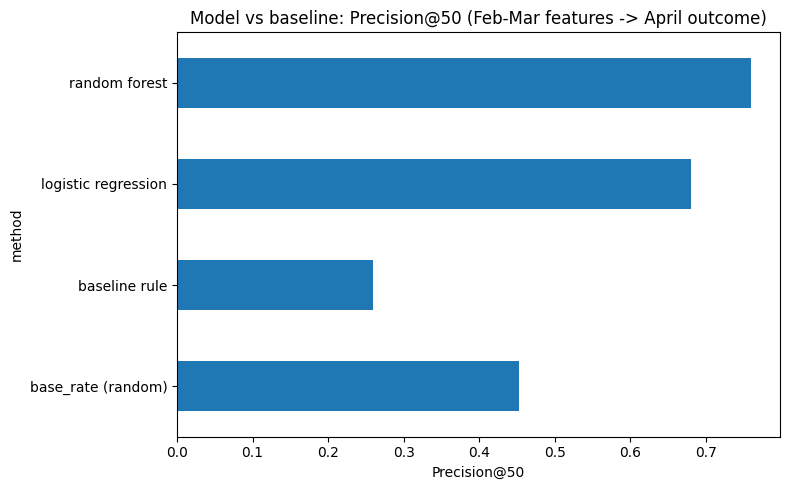

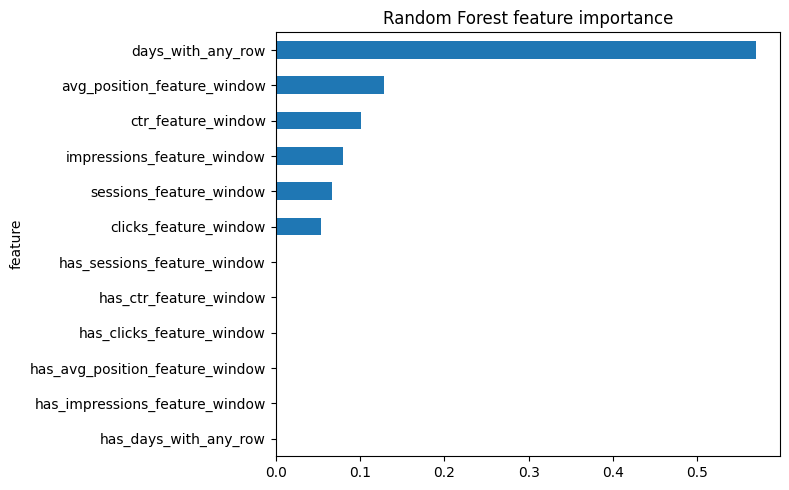

Exported:
 - work/outputs/capstone_metrics.json
 - work/outputs/capstone_ranked_queue.csv
 - work/figures/capstone_model_vs_baseline.png
 - work/figures/capstone_feature_importance.png


In [21]:
import json
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

ranked_queue.to_csv("work/outputs/capstone_ranked_queue.csv", index=False)

metrics_snapshot = {
    "date_generated": pd.Timestamp.now().strftime("%Y-%m-%d"),
    "feature_window": "2026-02-01 to 2026-03-31",
    "target_window": "2026-04-01 to 2026-04-30",
    "n_labeled_pages": int(len(model_df)),
    "n_train_clients": int(train_df["client_hash_id"].nunique()),
    "n_test_clients": int(test_df["client_hash_id"].nunique()),
    "base_rate": round(float(base_rate_test), 3),
    "baseline_precision_at_50": round(float(baseline_p50), 3),
    "logreg_precision_at_50": round(float(logreg_p50), 3),
    "rf_precision_at_50": round(float(rf_p50), 3),
    "leaky_stress_test_precision_at_50": round(float(p50_leaky), 3),
    "action_mix": test_df["suggested_action"].value_counts(normalize=True).round(3).to_dict(),
}
with open("work/outputs/capstone_metrics.json", "w") as f:
    json.dump(metrics_snapshot, f, indent=2, default=str)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
results.set_index("method")["precision@50"].plot(kind="barh", ax=ax)
ax.set_xlabel("Precision@50")
ax.set_title("Model vs baseline: Precision@50 (Feb-Mar features -> April outcome)")
plt.tight_layout()
plt.savefig("work/figures/capstone_model_vs_baseline.png", dpi=150)
plt.show()

fig2, ax2 = plt.subplots(figsize=(8, 5))
imp_df.sort_values("importance").plot(kind="barh", x="feature", y="importance", ax=ax2, legend=False)
ax2.set_title("Random Forest feature importance")
plt.tight_layout()
plt.savefig("work/figures/capstone_feature_importance.png", dpi=150)
plt.show()

print("Exported:")
for f in os.listdir("work/outputs"):
    print(" - work/outputs/" + f)
for f in os.listdir("work/figures"):
    print(" - work/figures/" + f)

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.